## SITCOM Laser Tracker Analysis: Static System Flexure

In [68]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time, TimeDelta
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lsst_efd_client import EfdClient

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
client = EfdClient('usdf_efd')
fields = ['dX', 'dY', 'dZ', 'dRX', 'dRY', 'target']

In [70]:
start = Time('2023-07-05 6:38:0Z', scale='utc')
end = Time('2023-07-05 10:40:0Z', scale='utc')

turned_jul05 = await client.select_time_series(
    'lsst.sal.LaserTracker.logevent_offsetsPublish',
    fields,  
    start, 
    end,
)  

start = Time('2024-01-12 20:30:0Z', scale='utc')
end = Time('2024-01-12 21:15:0Z', scale='utc')

turned_jan13 = await client.select_time_series(
    'lsst.sal.LaserTracker.logevent_offsetsPublish',
    fields,  
    start, 
    end,
)  

In [41]:
turned_jan13

,dX,dY,dZ,dRX,dRY,target
2024-01-12 20:31:32.813661+00:00,1.322249,0.532472,3023.026123,0.071302,0.005767,FrameCAM_86.00_153.00_-0.011
2024-01-12 20:34:13.330853+00:00,0.905017,-1.777372,5923.932617,0.012569,0.027877,FrameM2_86.00_153.00_-0.011
2024-01-12 20:37:03.504361+00:00,1.320072,0.446492,3023.020752,0.071403,0.005705,FrameCAM_85.00_153.00_-0.011
2024-01-12 20:39:54.474702+00:00,0.929287,-1.809523,5923.941406,0.012299,0.028078,FrameM2_85.00_153.00_-0.011
2024-01-12 20:42:47.741989+00:00,1.315968,0.255738,3023.034180,0.068413,0.005736,FrameCAM_80.00_153.00_-0.011
2024-01-12 20:45:41.478028+00:00,0.942363,-1.971996,5923.951660,0.011352,0.028594,FrameM2_80.00_153.00_-0.011
2024-01-12 20:48:29.432644+00:00,1.301192,0.074920,3023.049072,0.066182,0.005673,FrameCAM_75.00_153.00_-0.011
2024-01-12 20:51:09.684191+00:00,0.931088,-2.059192,5923.978516,0.008723,0.028266,FrameM2_75.00_153.00_-0.011
2024-01-12 20:54:08.482791+00:00,1.307009,-0.137512,3023.074219,0.064144,0.005876,FrameCAM_70.00_153.00_-0.011
2024-01-12 20:56:56.046885+00:00,0.936791,-2.194097,5924.005371,0.007531,0.028615,FrameM2_70.00_153.00_-0.011


In [65]:
def get_data(turned, target):
    if target == 'Camera':
        turned = turned.loc[turned['target'].str.startswith('FrameCAM')]
        turned['target_elevation'] = turned['target'].str[9:13].astype(float)
    elif target == 'M2':
        turned = turned.loc[turned['target'].str.startswith('FrameM2')]
        turned['target_elevation'] = turned['target'].str[8:12].astype(float)

    turned['dX'] *= 1e3
    turned['dY'] *= 1e3
    turned['dZ'] *= 1e3
    return turned

target = 'Camera'
data_jul05 = get_data(turned_jul05, target)
data_jan13 = get_data(turned_jan13, target)

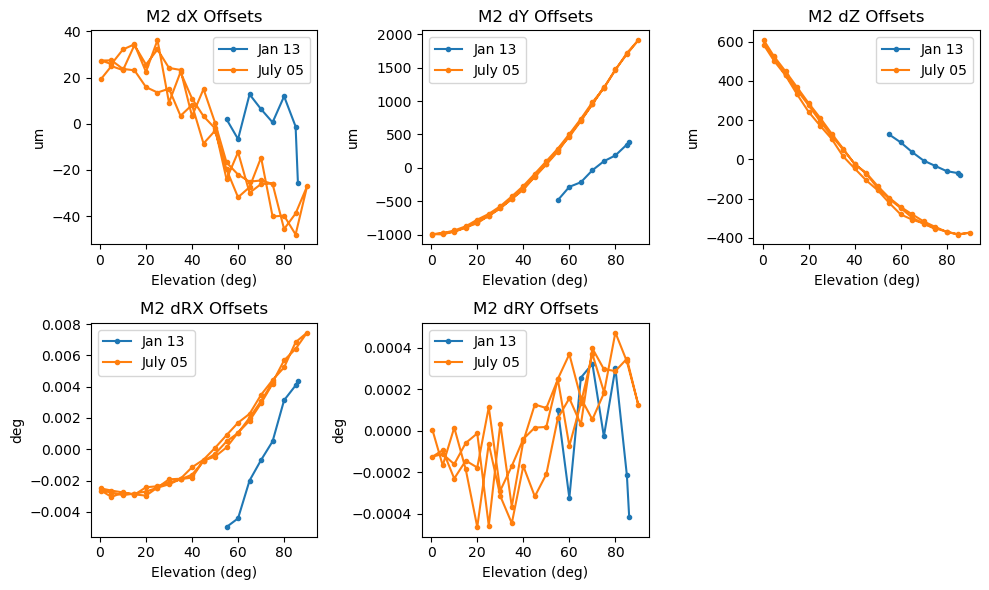

In [58]:
plt.figure(figsize = (10, 6))
for idx, field in enumerate(fields[:-1]):
    plt.subplot(2,3,idx + 1)
    if field == 'dZ':
        plt.plot(data_jan13['target_elevation'], data_jan13[field] - np.mean(data_jan13['dZ']), '.-', label = 'Jan 13')
        plt.plot(data_jul05['target_elevation'], data_jul05[field] - np.mean(data_jul05['dZ']), '.-', label = 'July 05')
    else:
        plt.plot(data_jan13['target_elevation'], data_jan13[field]- np.mean(data_jan13[field]), '.-', label = 'Jan 13')
        plt.plot(data_jul05['target_elevation'], data_jul05[field]- np.mean(data_jul05[field]), '.-', label = 'July 05')
        
    plt.xlabel('Elevation (deg)')
    if idx >= 3:
        plt.ylabel('deg')
    else:
        plt.ylabel('um')
    plt.title(f'{target} {field} Offsets')
    plt.legend()
    
    
plt.tight_layout()

Text(0.5, 0, 'Time (utc)')

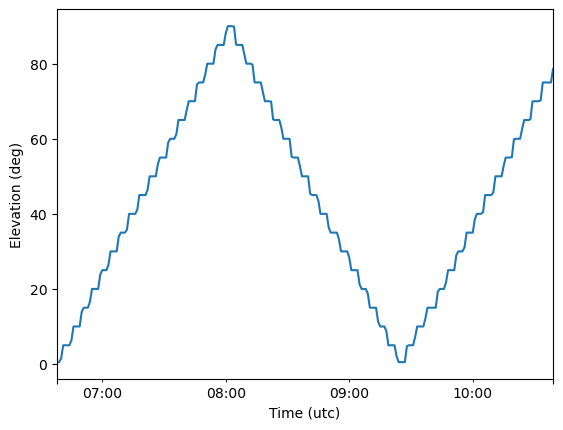

In [121]:
elevations = await client.select_time_series(
    'lsst.sal.MTMount.elevation',
    ['actualPosition', 'timestamp'],  
    start, 
    end,
)  
elevations = elevations['actualPosition'].resample('1T').mean()
elevations.plot()
plt.ylabel('Elevation (deg)')
plt.xlabel('Time (utc)')

In [47]:
import yaml 
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

with open('notebooks/ts_aos_utils/python/lsst/ts/aos/utils/data/hexapod/hexapod_lookuptables.yaml', 'r') as yaml_file:
    data = yaml.safe_load(yaml_file)

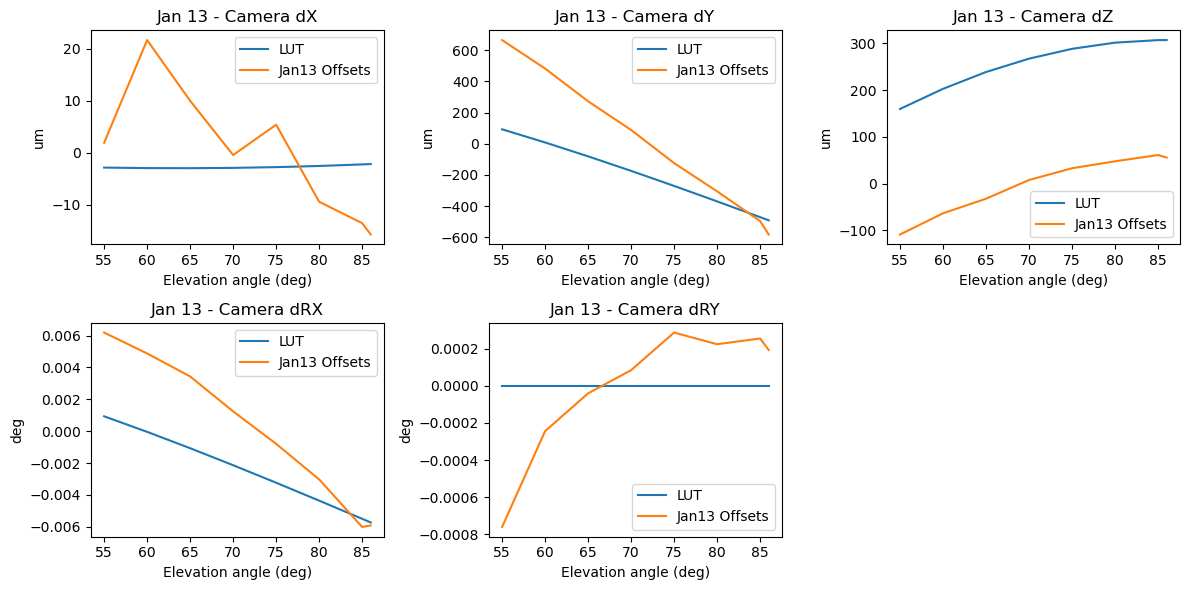

In [66]:
plt.figure(figsize=(12, 6))

for i, field in enumerate(fields[:-1]):
    coeffs = data["m2_config"]["elevation_coeffs"][i]
    plt.subplot(2,3,i + 1)
    y = np.polyval(coeffs[::-1],data_jan13['target_elevation'])  # Evaluate the polynomial
    plt.plot(data_jan13['target_elevation'], y, label=f'LUT')
    plt.plot(data_jan13['target_elevation'], -data_jan13[field] + np.mean(data_jan13[field]), label = 'Jan13 Offsets')
    plt.legend()
    plt.xlabel('Elevation angle (deg)')

    plt.title(f'Jan 13 - {target} {field}')
    if i < 3:
        plt.ylabel('um')
    else:
        plt.ylabel('deg')

plt.tight_layout()

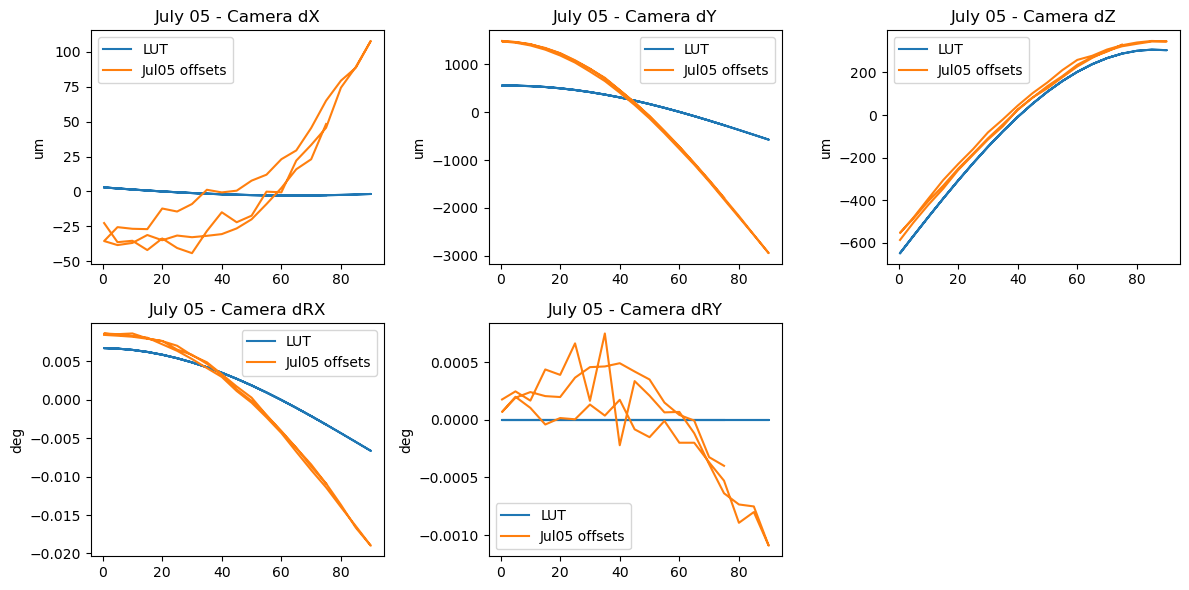

In [67]:
plt.figure(figsize=(12, 6))

for i, field in enumerate(fields[:-1]):
    coeffs = data["m2_config"]["elevation_coeffs"][i]
    plt.subplot(2,3,i + 1)
    y = np.polyval(coeffs[::-1], data_jul05['target_elevation'])  # Evaluate the polynomial
    plt.plot(data_jul05['target_elevation'], y, label=f'LUT')
    plt.plot(data_jul05['target_elevation'], -data_jul05[field] + np.mean(data_jul05[field]), label = 'Jul05 offsets')
    plt.legend()
    plt.title(f'July 05 - {target} {field}')
    if i < 3:
        plt.ylabel('um')
    else:
        plt.ylabel('deg')

plt.tight_layout()

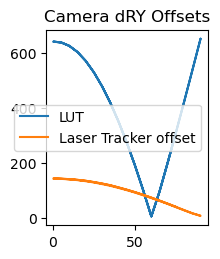

In [97]:

coeffs = data["camera_config"]["elevation_coeffs"][0]
coeffs2 = data["camera_config"]["elevation_coeffs"][1]
plt.subplot(2,3,i + 1)
y = np.polyval(coeffs[::-1], turned['target_elevation']) 
y2 = np.polyval(coeffs2[::-1], turned['target_elevation']) # Evaluate the polynomial
plt.plot(turned['target_elevation'], np.sqrt(y**2 + y2**2), label=f'LUT')
plt.plot(turned['target_elevation'], np.sqrt(1e-3*turned['dX']**2 +  1e-3*turned['dY']**2), label = 'Laser Tracker offset')
plt.legend()
plt.title(f'{target} {field} Offsets')
plt.tight_layout()